## Import Library

In [11]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [13]:
img_nama = cv2.imread("nama.jpeg")

In [14]:
img_nama.shape

(1200, 1600, 3)

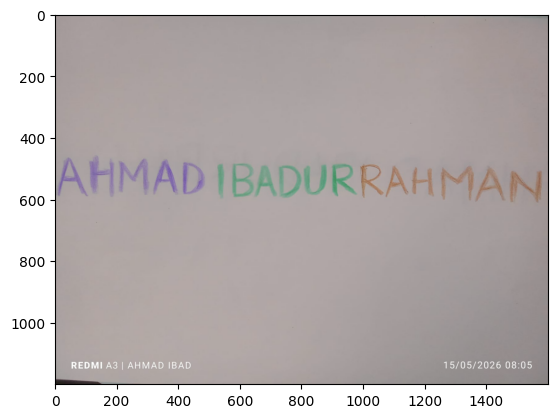

In [15]:
plt.imshow(img_nama)

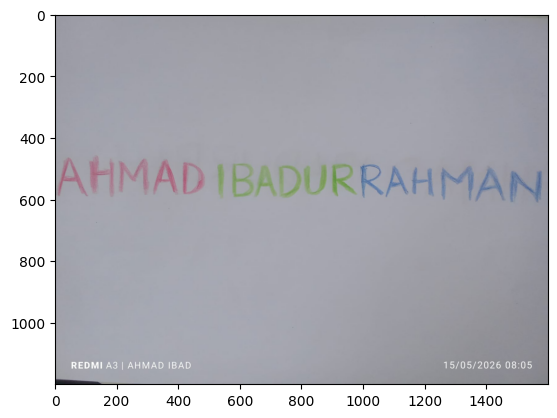

In [16]:
img_rgb = cv2.cvtColor(img_nama, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [17]:
R, G, B = cv2.split(img_rgb)

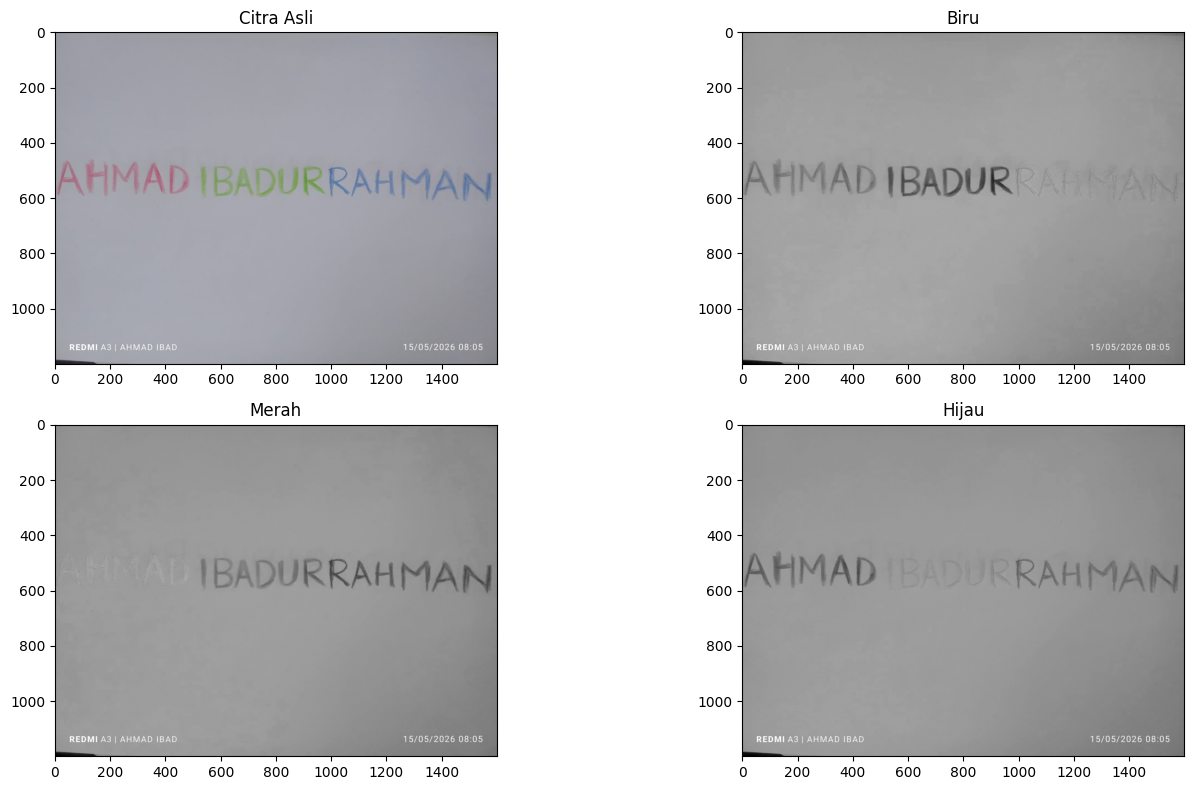

In [18]:
# Menampilkan hasil pemisahan kanal warna
fig, axs = plt.subplots(2, 2, figsize=(15, 8))
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Asli')

axs[0, 1].imshow(B, cmap='gray')
axs[0, 1].set_title('Biru')

axs[1, 0].imshow(R, cmap='gray')
axs[1, 0].set_title('Merah')

axs[1, 1].imshow(G, cmap='gray')
axs[1, 1].set_title('Hijau')

plt.tight_layout()
plt.show()

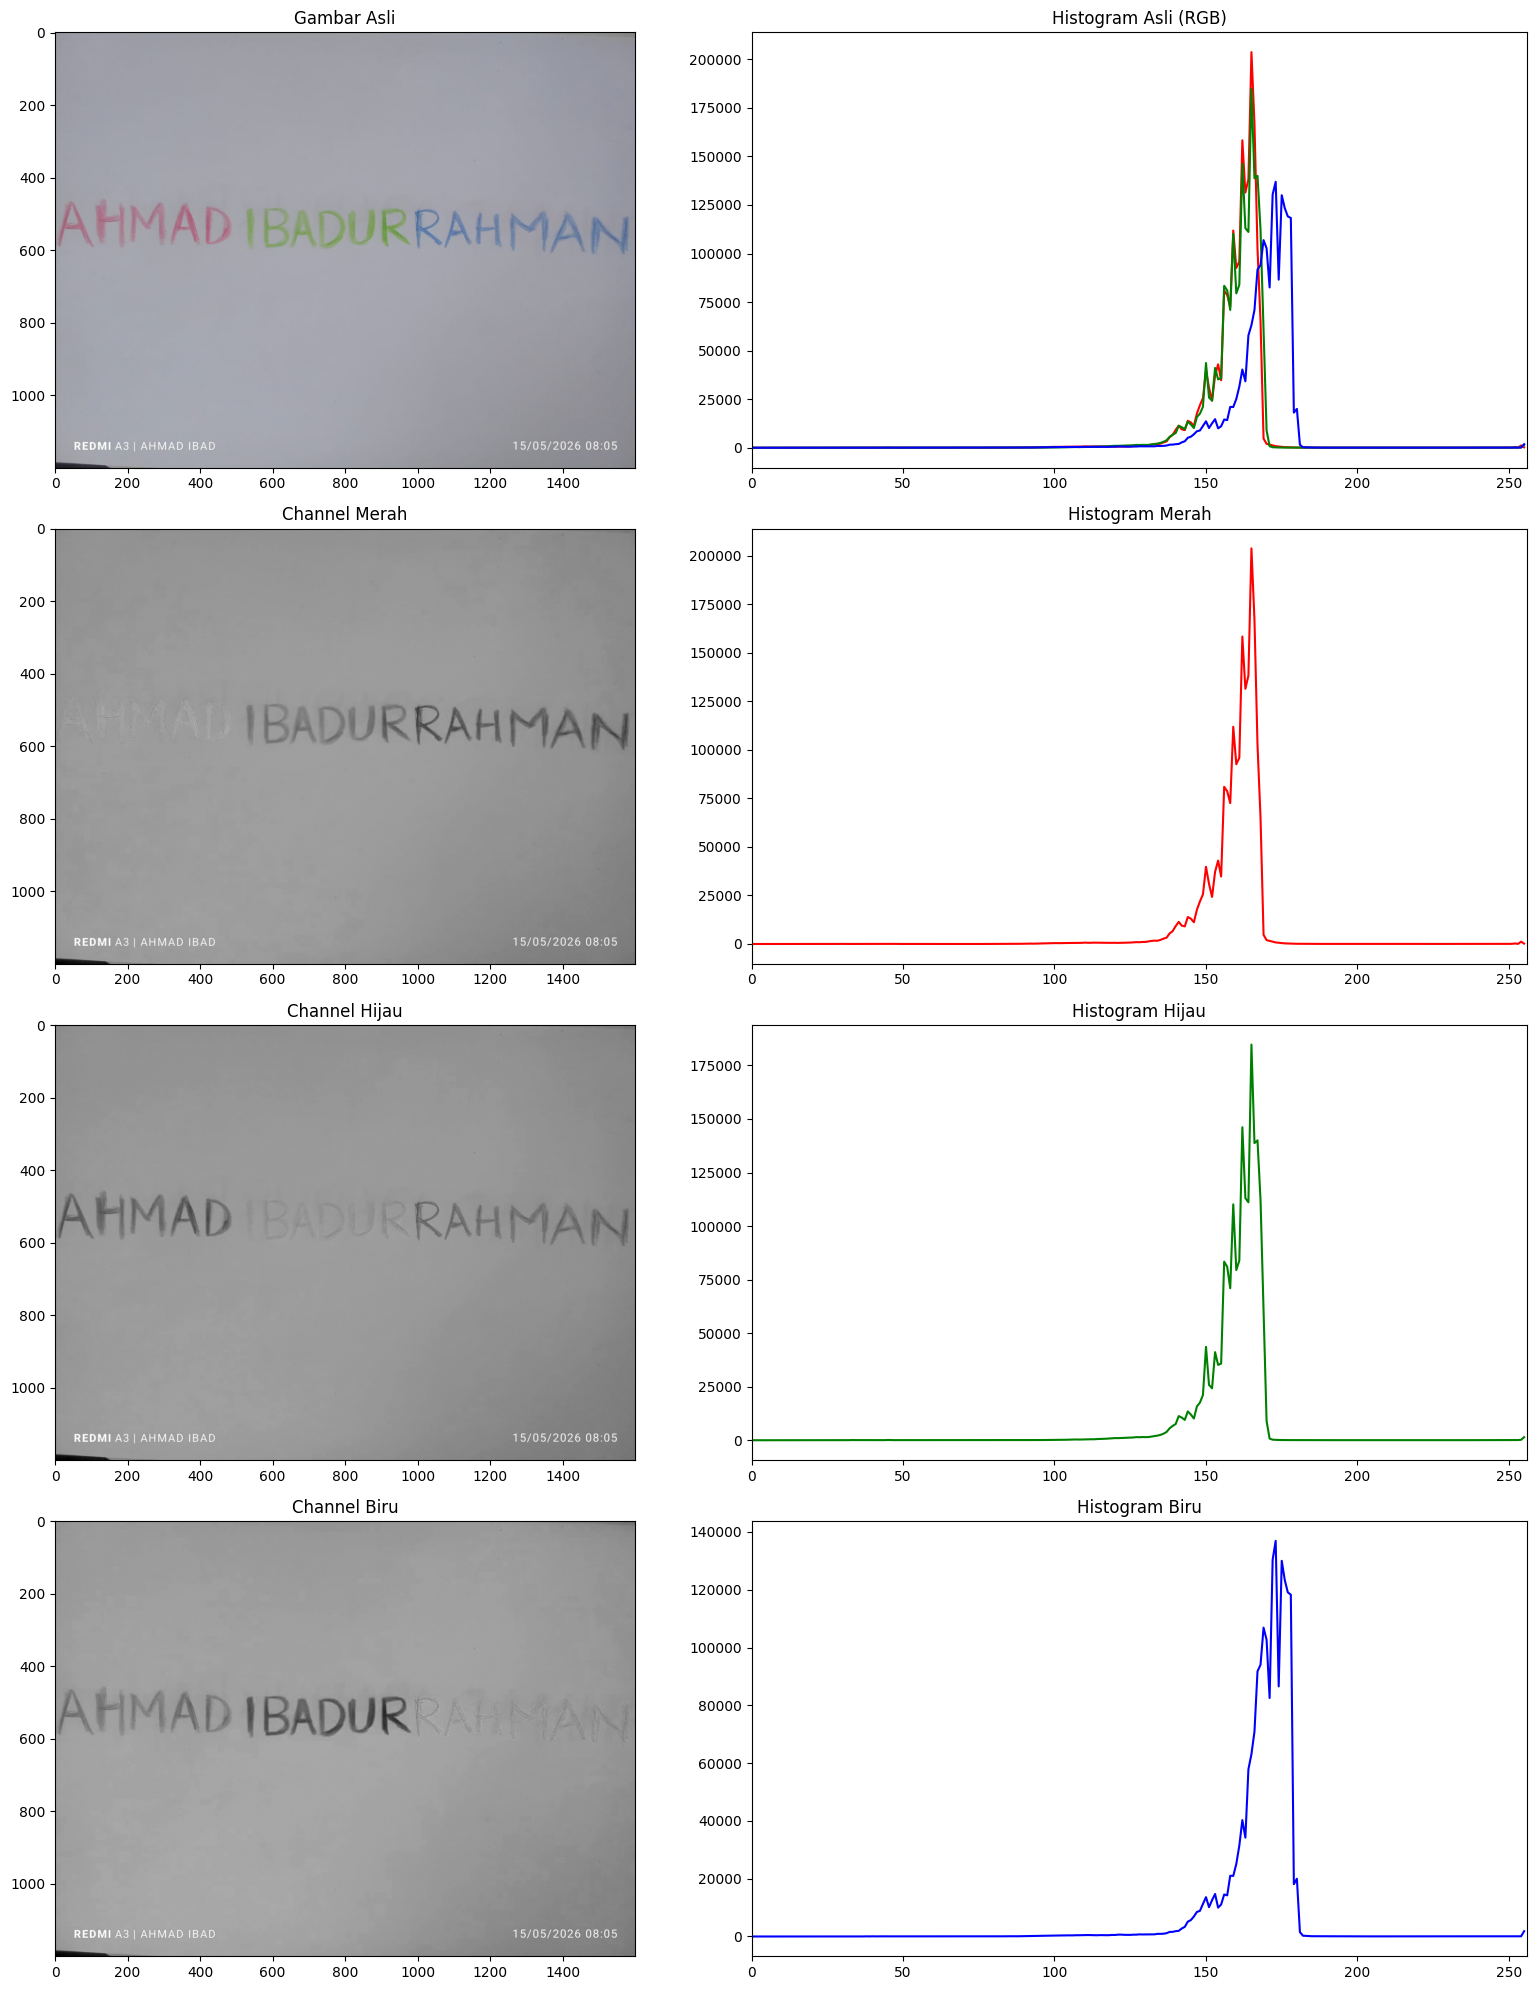

In [19]:
# Menghitung histogram untuk masing-masing kanal
hist_R = cv2.calcHist([img_rgb], [0], None, [256], [0, 256])
hist_G = cv2.calcHist([img_rgb], [1], None, [256], [0, 256])
hist_B = cv2.calcHist([img_rgb], [2], None, [256], [0, 256])

fig, axs = plt.subplots(4, 2, figsize=(16, 20))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Gambar Asli')

axs[0, 1].plot(hist_R, color='r', label='Merah')
axs[0, 1].plot(hist_G, color='g', label='Hijau')
axs[0, 1].plot(hist_B, color='b', label='Biru')
axs[0, 1].set_title('Histogram Asli (RGB)')
axs[0, 1].set_xlim([0, 256])

axs[1, 0].imshow(R, cmap='gray')
axs[1, 0].set_title('Channel Merah')

axs[1, 1].plot(hist_R, color='r')
axs[1, 1].set_title('Histogram Merah')
axs[1, 1].set_xlim([0, 256])

axs[2, 0].imshow(G, cmap='gray')
axs[2, 0].set_title('Channel Hijau')

axs[2, 1].plot(hist_G, color='g')
axs[2, 1].set_title('Histogram Hijau')
axs[2, 1].set_xlim([0, 256])

axs[3, 0].imshow(B, cmap='gray')
axs[3, 0].set_title('Channel Biru')

axs[3, 1].plot(hist_B, color='b')
axs[3, 1].set_title('Histogram Biru')
axs[3, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

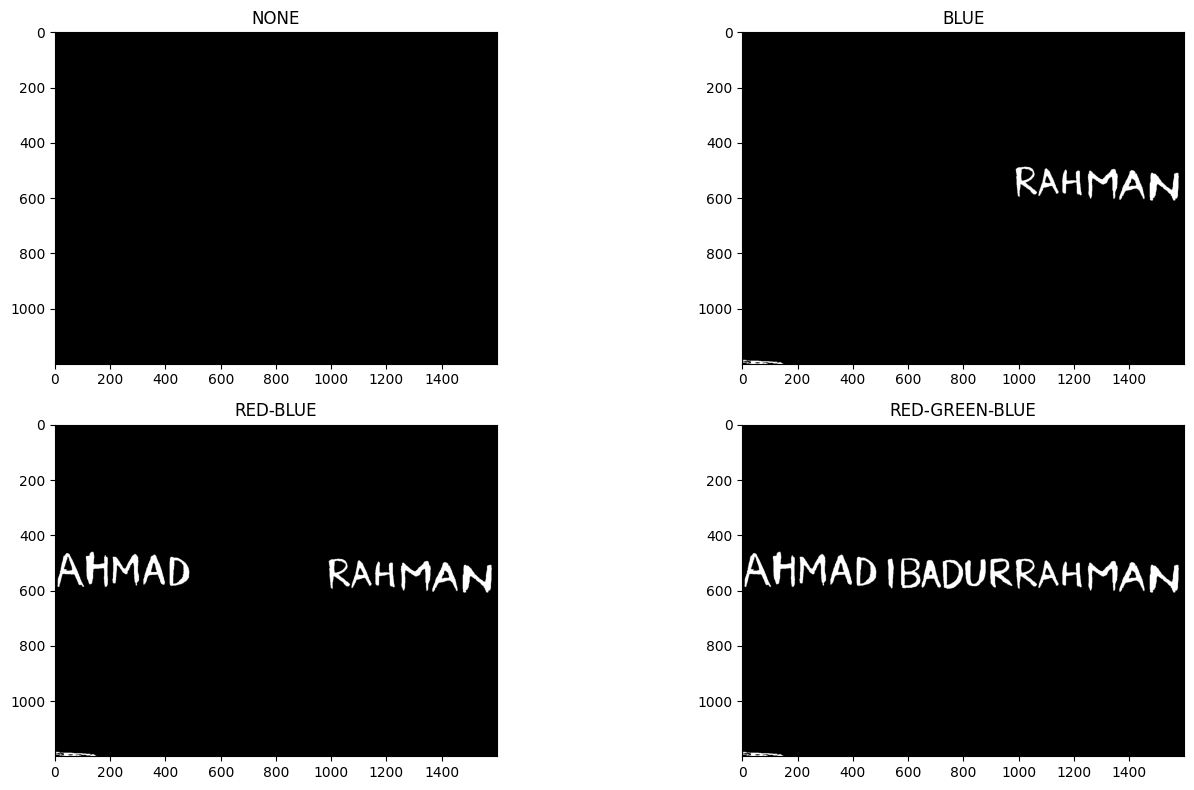

In [20]:
# Menggunakan konversi HSV untuk memisahkan warna
hsv_img = cv2.cvtColor(img_nama, cv2.COLOR_BGR2HSV)

# Menentukan ambang batas untuk Biru ("RAHMAN")
lower_blue = np.array([90, 40, 40])
upper_blue = np.array([140, 255, 255])
mask_blue = cv2.inRange(hsv_img, lower_blue, upper_blue)

# Menentukan ambang batas untuk Merah ("AHMAD")
lower_red1 = np.array([0, 30, 30])
upper_red1 = np.array([20, 255, 255])
lower_red2 = np.array([160, 30, 30])
upper_red2 = np.array([180, 255, 255])
mask_red = cv2.inRange(hsv_img, lower_red1, upper_red1) | cv2.inRange(hsv_img, lower_red2, upper_red2)

# Menentukan ambang batas untuk Hijau ("IBADUR")
lower_green = np.array([35, 30, 30])
upper_green = np.array([85, 255, 255])
mask_green = cv2.inRange(hsv_img, lower_green, upper_green)

# Mengkombinasikan Masking sesuai soal (NONE, BLUE, RED-BLUE, RED-GREEN-BLUE)
mask_none = np.zeros_like(mask_blue)
mask_red_blue = cv2.bitwise_or(mask_red, mask_blue)
mask_all = cv2.bitwise_or(mask_red_blue, mask_green)

# Visualisasi Hasil
fig, axs = plt.subplots(2, 2, figsize=(15, 8))
axs[0, 0].imshow(mask_none, cmap='gray')
axs[0, 0].set_title('NONE')

axs[0, 1].imshow(mask_blue, cmap='gray')
axs[0, 1].set_title('BLUE')

axs[1, 0].imshow(mask_red_blue, cmap='gray')
axs[1, 0].set_title('RED-BLUE')

axs[1, 1].imshow(mask_all, cmap='gray')
axs[1, 1].set_title('RED-GREEN-BLUE')

plt.tight_layout()
plt.show()

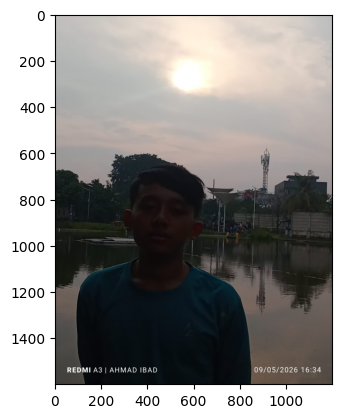

In [21]:
img_backlight = cv2.imread('foto_diri.jpeg')
img_backlight_rgb = cv2.cvtColor(img_backlight, cv2.COLOR_BGR2RGB)
plt.imshow(img_backlight_rgb)

In [22]:
[baris, kolom] = img_backlight.shape[:2]

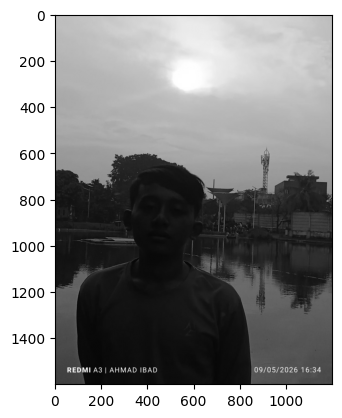

In [23]:
img_gray = cv2.cvtColor(img_backlight, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray, cmap= 'gray')

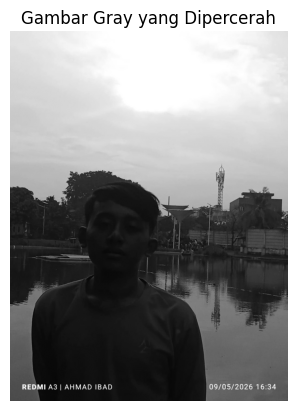

In [36]:
beta = 40
citra_cerah = np.zeros((baris, kolom)) 

for x in range(baris):
    for y in range(kolom):
        gyx = int(img_gray[x, y]) + beta 
        
        if gyx > 255:
            gyx = 255
            
        citra_cerah[x, y] = gyx

citra_cerah = citra_cerah.astype(np.uint8)

plt.imshow(citra_cerah, cmap='gray')
plt.title("Gambar Gray yang Dipercerah")
plt.axis("off")
plt.show()

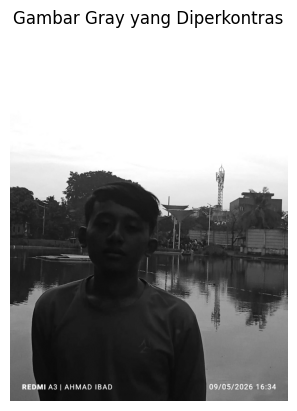

In [37]:
alpha = 1.5
citra_kontras = np.zeros((baris, kolom))

for x in range(baris):
    for y in range(kolom):
        gyx = int(img_gray[x, y]) * alpha
        
        if gyx > 255:
            gyx = 255
            
        citra_kontras[x, y] = gyx

citra_kontras = citra_kontras.astype(np.uint8)

plt.imshow(citra_kontras, cmap='gray')
plt.title("Gambar Gray yang Diperkontras")
plt.axis("off")
plt.show()

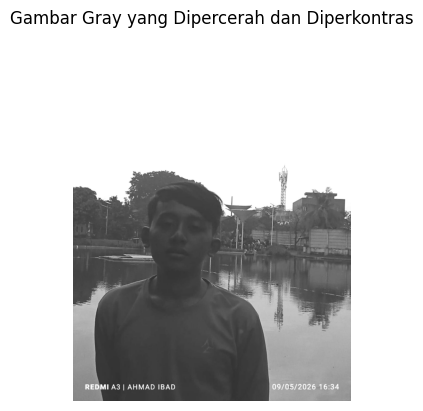

In [38]:
beta = 40
alpha = 1.5
citra_hasil = np.zeros((baris, kolom, 3))

for x in range(baris):
    for y in range(kolom):
        gyx = int(img_gray[x, y]) * alpha + beta
        
        if gyx > 255:
            gyx = 255
            
        citra_hasil[x, y] = gyx

citra_hasil = citra_hasil.astype(np.uint8)

plt.imshow(citra_hasil, cmap='gray')
plt.title("Gambar Gray yang Dipercerah dan Diperkontras")
plt.axis("off")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11904\652924733.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1, 1].hist(img_gray.ravel(), 256, [0, 256], color='gray')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11904\652924733.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[2, 1].hist(citra_cerah.ravel(), 256, [0, 256], color='gray')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11904\652924733.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[3, 1].hist(citra_kontras.ravel(), 256, [0, 256], color='gray')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11904\652924733.py:37: MatplotlibDeprecationWarning: 

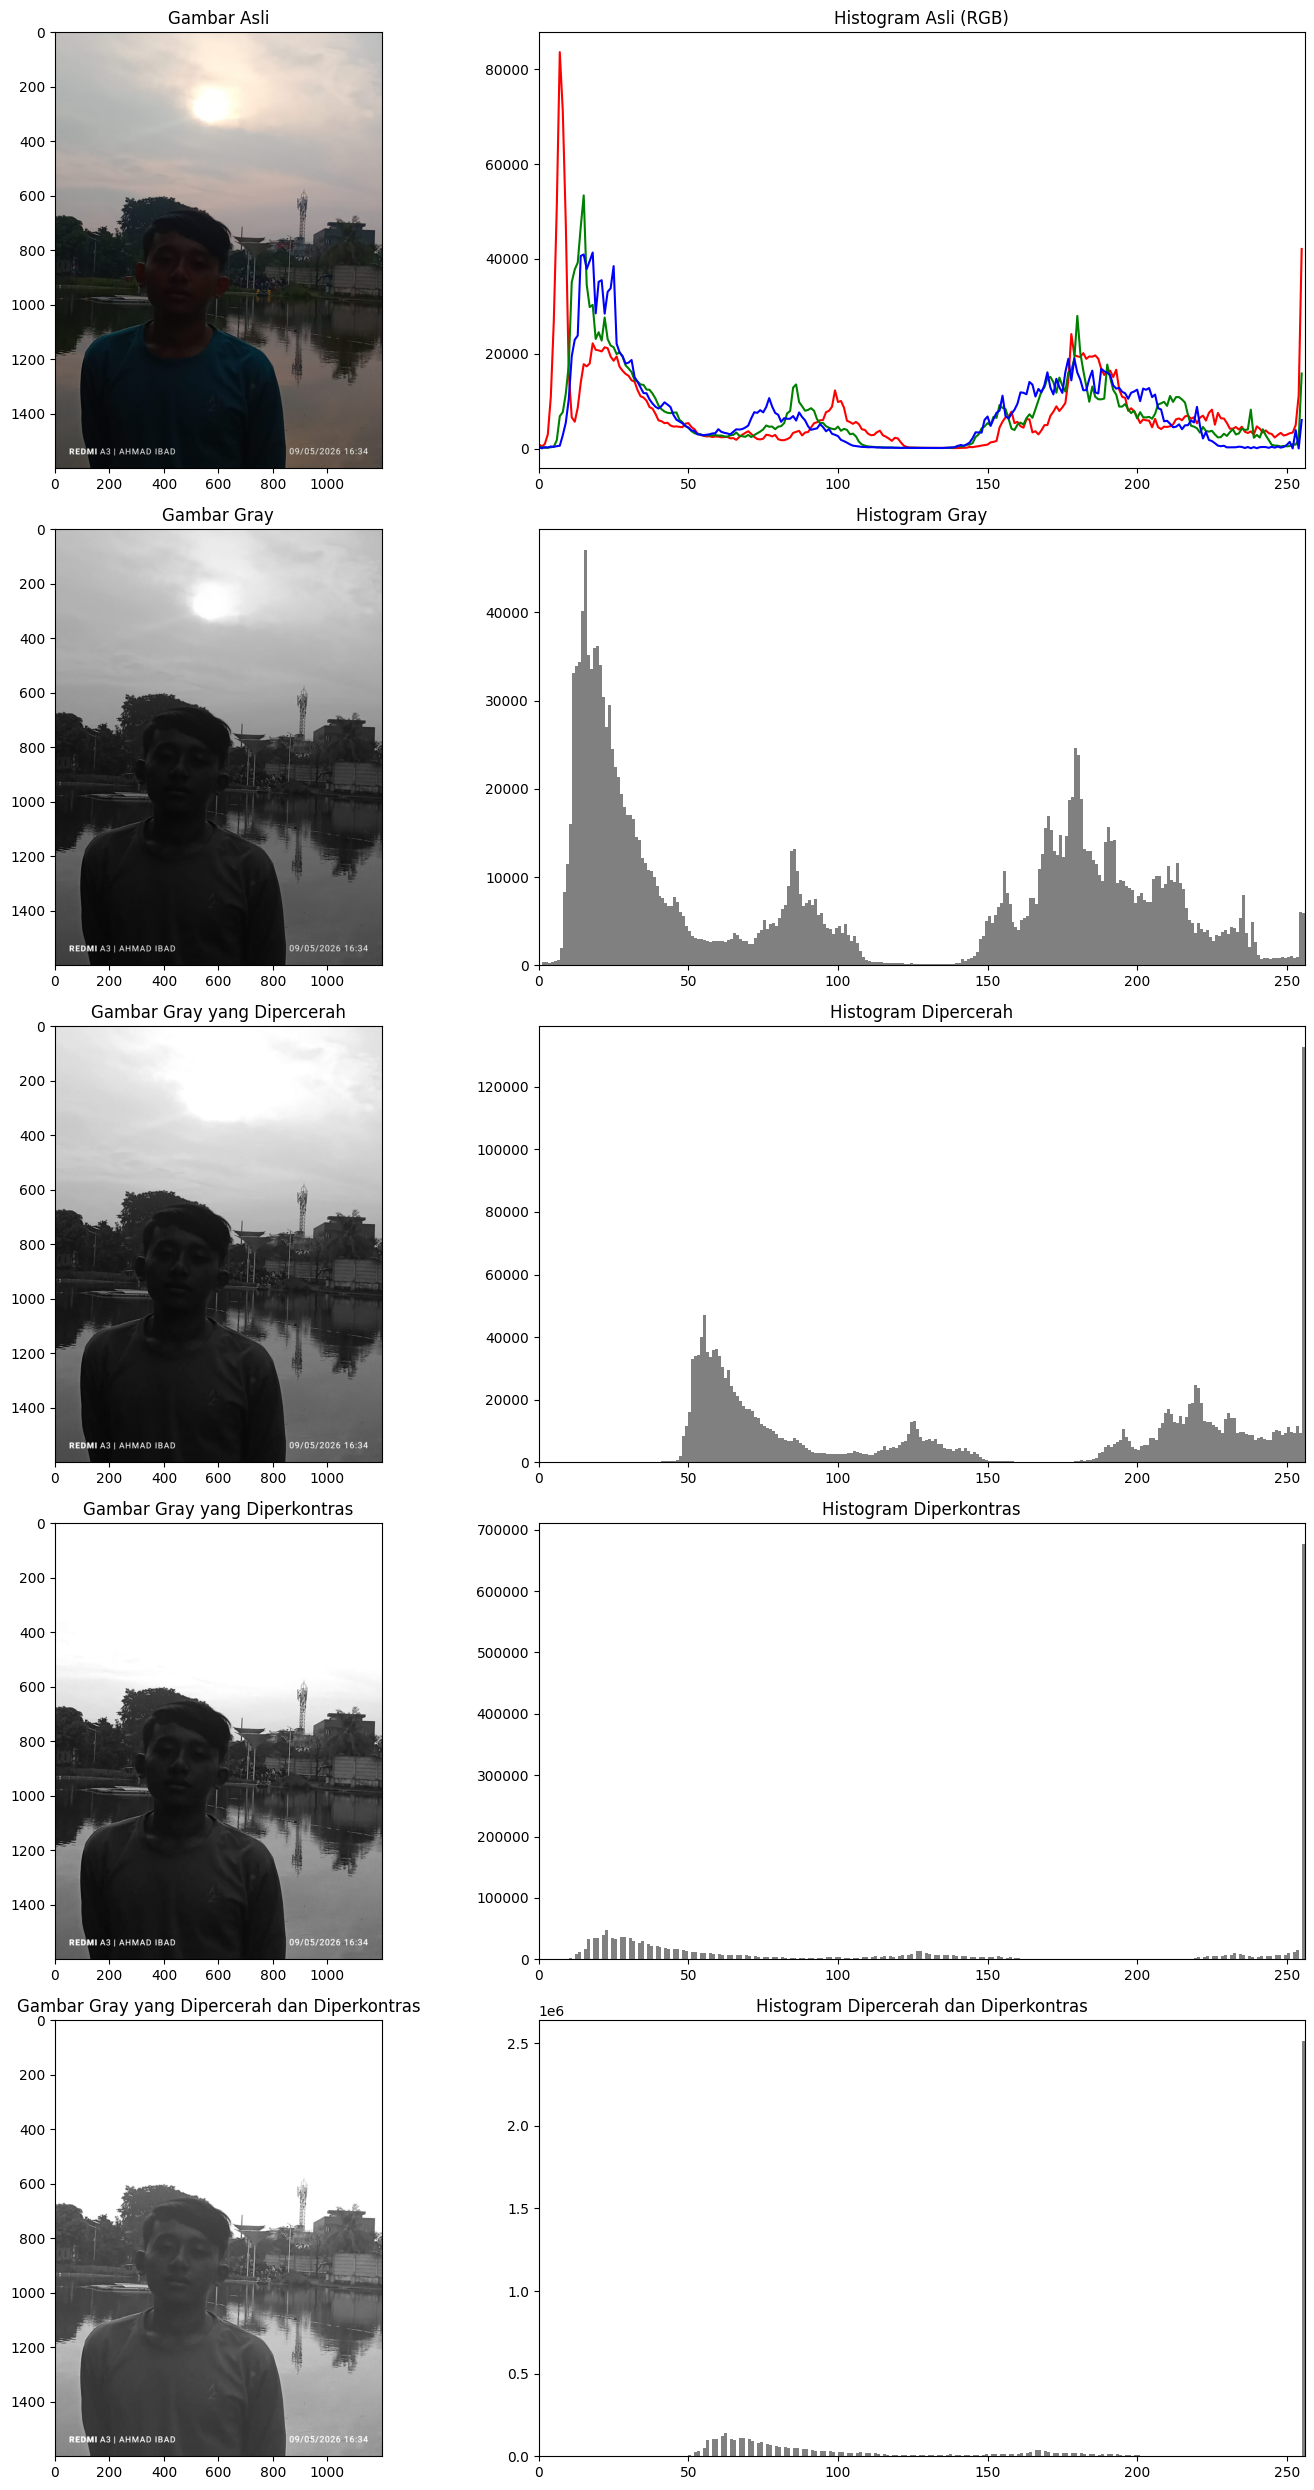

In [39]:
fig, axs = plt.subplots(5, 2, figsize=(15, 25))

axs[0, 0].imshow(img_backlight_rgb)
axs[0, 0].set_title('Gambar Asli')

colors = ('r', 'g', 'b')
for i, col in enumerate(colors):
    hist_rgb = cv2.calcHist([img_backlight_rgb], [i], None, [256], [0, 256])
    axs[0, 1].plot(hist_rgb, color=col)
axs[0, 1].set_title('Histogram Asli (RGB)')
axs[0, 1].set_xlim([0, 256])

axs[1, 0].imshow(img_gray, cmap='gray')
axs[1, 0].set_title('Gambar Gray')

axs[1, 1].hist(img_gray.ravel(), 256, [0, 256], color='gray')
axs[1, 1].set_title('Histogram Gray')
axs[1, 1].set_xlim([0, 256])

axs[2, 0].imshow(citra_cerah, cmap='gray')
axs[2, 0].set_title('Gambar Gray yang Dipercerah')

axs[2, 1].hist(citra_cerah.ravel(), 256, [0, 256], color='gray')
axs[2, 1].set_title('Histogram Dipercerah')
axs[2, 1].set_xlim([0, 256])

axs[3, 0].imshow(citra_kontras, cmap='gray')
axs[3, 0].set_title('Gambar Gray yang Diperkontras')

axs[3, 1].hist(citra_kontras.ravel(), 256, [0, 256], color='gray')
axs[3, 1].set_title('Histogram Diperkontras')
axs[3, 1].set_xlim([0, 256])

axs[4, 0].imshow(citra_hasil, cmap='gray')
axs[4, 0].set_title('Gambar Gray yang Dipercerah dan Diperkontras')

axs[4, 1].hist(citra_hasil.ravel(), 256, [0, 256], color='gray')
axs[4, 1].set_title('Histogram Dipercerah dan Diperkontras')
axs[4, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()